# Семинар 4: Свёрточные нейронные сети

На этом занятии мы перейдём от полносвязных моделей к свёрточным нейронным сетям (CNN)

Основные темы семинара:
- Построение двумерных мел-спектрограмм как входного признака для CNN.
- Свёрточные слои (`Conv2d`), пуллинг, пакетная нормализация.
- Архитектура CNN для классификации дикторов.
- Обучение и оценка модели на подмножестве дикторов.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchaudio
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os

from dataset import AudioMNISTDataset

torch.manual_seed(42)
np.random.seed(42)

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
# %pip install gdown -q

In [ ]:
import gdown
import zipfile

FILE_ID = "13E8JVJdNYS9K9ubdGcruLSMLUD10OLbx"
output = "audio_mnist.zip"

if not os.path.exists(output):
    gdown.download(id=FILE_ID, output=output, quiet=False)

# Распаковка
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(".")

In [4]:
# Попробуем использовать MPS (Apple Silicon) или CUDA, иначе CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Используемое устройство: {device}")

Используемое устройство: mps


In [5]:
# Параметры аудио
SAMPLE_RATE = 16000
TARGET_LEN = 3
N_FFT = 256
HOP_LENGTH = 256
WIN_LENGTH = 256

In [6]:
full_dataset = AudioMNISTDataset('data', SAMPLE_RATE * TARGET_LEN)
train_ratio = 0.8
train_size = int(len(full_dataset) * train_ratio)
val_size = len(full_dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

Найдено 30000 аудиофайлов


In [7]:
BATCH_SIZE = 64
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=8)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [8]:
def stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH):
    """Wrapper of the official torch.stft for single-channel and multi-channel.

    Args:
        y: single- or multi-channel speech with shape of [B, C, T] or [B, T]
        n_fft: number of FFT
        hop_length: hop length
        win_length: hanning window size

    Shapes:
        mag: [B, F, T] if dims of input is [B, T], whereas [B, C, F, T] if dims of input is [B, C, T]

    Returns:
        mag, phase, real and imag with the same shape of [B, F, T] (**complex-valued** STFT coefficients)
    """
    num_dims = y.dim()
    assert num_dims == 2 or num_dims == 3, "Only support 2D or 3D Input"

    batch_size = y.shape[0]
    num_samples = y.shape[-1]

    if num_dims == 3:
        y = y.reshape(-1, num_samples)  # [B * C ,T]

    complex_stft = torch.stft(
        y,
        n_fft,
        hop_length,
        win_length,
        window=torch.hann_window(n_fft, device=y.device),
        return_complex=True,
    )
    _, num_freqs, num_frames = complex_stft.shape

    if num_dims == 3:
        complex_stft = complex_stft.reshape(batch_size, -1, num_freqs, num_frames)

    mag = torch.abs(complex_stft)
    phase = torch.angle(complex_stft)
    real = complex_stft.real
    imag = complex_stft.imag
    return mag, phase, real, imag

In [9]:
stft(full_dataset[0][0].unsqueeze(0))[0].shape

torch.Size([1, 129, 188])

## 2. Свёрточная модель (2D CNN)

Двумерная свёртка `Conv2d(in_channels, out_channels, kernel_size, stride)`
В нашей модели несколько свёрточных слоёв увеличивают количество каналов, а Pooling и AdaptiveAvgPool уменьшают временное и частотное разрешение, после чего линейный классификатор выдаёт ответ.

In [24]:
class Audio2DCNN(nn.Module):
    def __init__(self, num_classes=10, dropout_prob=0.5):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1, stride=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.maxpool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1, stride=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1, stride=1)
        self.bn3 = nn.BatchNorm2d(64)

        # 3 блока
        # свертка с ядром 3, sride и pad = 1
        # max pool
        # batchnord2D

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout_prob)
        self.fc1 = nn.Linear(in_features=64, out_features=32)
        self.fc2 = nn.Linear(in_features=32, out_features=num_classes)

        # nn.Flatten
        # Linear слой для классификации

    def forward(self, x):
        # x: (B, 1, H, W)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.dropout(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x


In [25]:
from torchinfo import summary
dummy = torch.randn(2, 1, 127, 188)
model = Audio2DCNN(num_classes=10)
print(summary(model, input_data=dummy))

Layer (type:depth-idx)                   Output Shape              Param #
Audio2DCNN                               [2, 10]                   --
├─Conv2d: 1-1                            [2, 16, 127, 188]         160
├─BatchNorm2d: 1-2                       [2, 16, 127, 188]         32
├─ReLU: 1-3                              [2, 16, 127, 188]         --
├─MaxPool2d: 1-4                         [2, 16, 63, 94]           --
├─Conv2d: 1-5                            [2, 32, 63, 94]           4,640
├─BatchNorm2d: 1-6                       [2, 32, 63, 94]           64
├─ReLU: 1-7                              [2, 32, 63, 94]           --
├─MaxPool2d: 1-8                         [2, 32, 31, 47]           --
├─Conv2d: 1-9                            [2, 64, 31, 47]           18,496
├─BatchNorm2d: 1-10                      [2, 64, 31, 47]           128
├─ReLU: 1-11                             [2, 64, 31, 47]           --
├─MaxPool2d: 1-12                        [2, 64, 15, 23]           --
├─Adap

In [26]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in tqdm(loader, desc="Train", leave=False):
        x, y = x.to(device), y.to(device)
        mag, phase, real, imag = stft(x)

        optimizer.zero_grad()
        logits = model(mag.unsqueeze(1))
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in tqdm(loader, desc="Eval", leave=False):
        x, y = x.to(device), y.to(device)
        mag, phase, real, imag = stft(x)
        logits = model(mag.unsqueeze(1))
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

In [27]:
model = Audio2DCNN(num_classes=10, dropout_prob=0.1).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
# Планировщик: уменьшаем lr в 2 раза каждые 3 эпохи
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

EPOCHS = 5

history = {"train_loss": [], "val_loss": [],
           "train_acc": [], "val_acc": []}

In [28]:
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    lr = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch+1:2d} | LR: {lr:.6f} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2%} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2%}")

Train:   0%|          | 0/375 [00:00<?, ?it/s]

Eval:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch  1 | LR: 0.001000 | Train Loss: 1.3536 Acc: 58.48% | Val Loss: 0.6070 Acc: 85.93%


Train:   0%|          | 0/375 [00:00<?, ?it/s]

Eval:   0%|          | 0/94 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch  4 | LR: 0.000500 | Train Loss: 0.2000 Acc: 94.52% | Val Loss: 0.2376 Acc: 92.15%


Train:   0%|          | 0/375 [00:00<?, ?it/s]

Eval:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch  5 | LR: 0.000500 | Train Loss: 0.1758 Acc: 95.17% | Val Loss: 0.2418 Acc: 92.33%


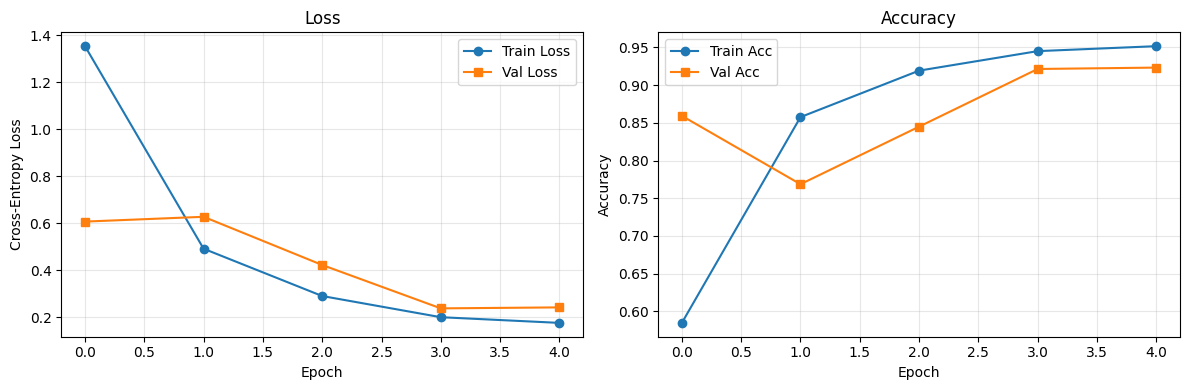

In [29]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], marker="o", label="Train Loss")
plt.plot(history["val_loss"], marker="s", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], marker="o", label="Train Acc")
plt.plot(history["val_acc"], marker="s", label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Accuracy")

plt.tight_layout()
plt.show()

## 3. Архитектура WaveformCNN

Одномерная свёртка (`Conv1d`) скользит вдоль временной оси, выделяя локальные паттерны.
За счёт большого `kernel_size` (64, 32, 16) и агрессивного `stride` мы быстро уменьшаем размерность и увеличиваем число каналов.

Такая конфигурация превращает 16000 отсчётов в 64‑мерный вектор признаков, поступающий на классификатор.

In [38]:
class WaveformCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=64, padding=32, stride=32)
        self.bn1 = nn.BatchNorm1d(num_features=16)
        self.avgpool = nn.AvgPool1d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()

        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=32, padding=16, stride=16)
        self.bn2 = nn.BatchNorm1d(num_features=32)
        self.avgpool = nn.AvgPool1d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()

        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=16, padding=8, stride=8)
        self.bn3 = nn.BatchNorm1d(num_features=64)
        self.avgpool = nn.AvgPool1d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()

        self.adaptavgpool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(in_features=64, out_features=num_classes)

    def forward(self, x):
        # x: (batch, 1, T)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.avgpool(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.avgpool(x)
        x = self.relu(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.avgpool(x)
        x = self.relu(x)

        x = self.adaptavgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

In [39]:
# Проверка размеров
dummy = torch.randn(2, 1, 48000)
model = WaveformCNN(num_classes=10)
print(summary(model, input_data=dummy))

Layer (type:depth-idx)                   Output Shape              Param #
WaveformCNN                              [2, 10]                   --
├─Conv1d: 1-1                            [2, 16, 1501]             1,040
├─BatchNorm1d: 1-2                       [2, 16, 1501]             32
├─AvgPool1d: 1-3                         [2, 16, 750]              --
├─ReLU: 1-4                              [2, 16, 750]              --
├─Conv1d: 1-5                            [2, 32, 47]               16,416
├─BatchNorm1d: 1-6                       [2, 32, 47]               64
├─AvgPool1d: 1-7                         [2, 32, 23]               --
├─ReLU: 1-8                              [2, 32, 23]               --
├─Conv1d: 1-9                            [2, 64, 3]                32,832
├─BatchNorm1d: 1-10                      [2, 64, 3]                128
├─AvgPool1d: 1-11                        [2, 64, 1]                --
├─ReLU: 1-12                             [2, 64, 1]                --
├─A

In [40]:
model = WaveformCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

EPOCHS = 5

history = {"train_loss": [], "val_loss": [],
           "train_acc": [], "val_acc": []}

In [41]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in tqdm(loader, desc="Train", leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x.unsqueeze(1))
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in tqdm(loader, desc="Eval", leave=False):
        x, y = x.to(device), y.to(device)
        logits = model(x.unsqueeze(1))
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

In [42]:
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    lr = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch+1:2d} | LR: {lr:.6f} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2%} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2%}")

Train:   0%|          | 0/375 [00:00<?, ?it/s]

Eval:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch  1 | LR: 0.001000 | Train Loss: 0.6658 Acc: 80.80% | Val Loss: 0.3162 Acc: 90.93%


Train:   0%|          | 0/375 [00:00<?, ?it/s]

Eval:   0%|          | 0/94 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch  4 | LR: 0.000500 | Train Loss: 0.0725 Acc: 98.10% | Val Loss: 0.1040 Acc: 97.02%


Train:   0%|          | 0/375 [00:00<?, ?it/s]

Eval:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch  5 | LR: 0.000500 | Train Loss: 0.0557 Acc: 98.64% | Val Loss: 0.1502 Acc: 95.33%


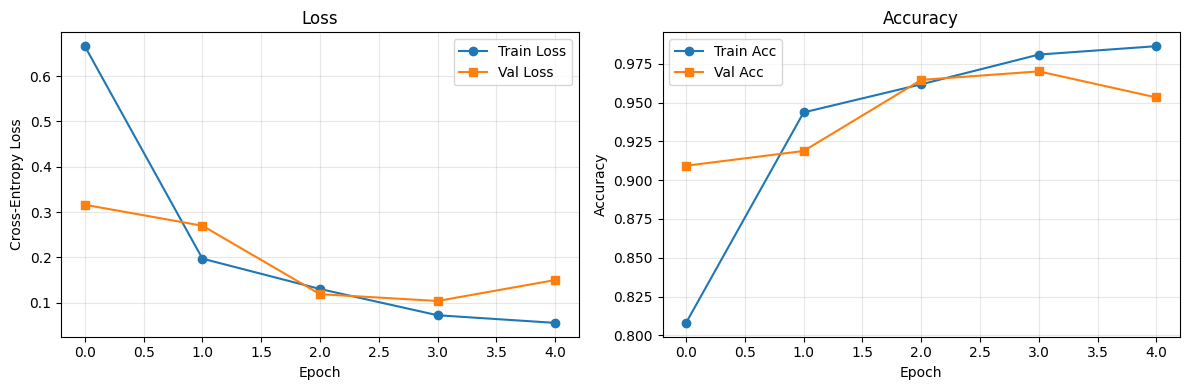

In [43]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], marker="o", label="Train Loss")
plt.plot(history["val_loss"], marker="s", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], marker="o", label="Train Acc")
plt.plot(history["val_acc"], marker="s", label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Accuracy")

plt.tight_layout()
plt.show()